In [ ]:
!pip install -q tensorflow tensorflow-model-optimization ultralytics

from google.colab import drive
drive.mount('/content/drive')

import os, tempfile, zipfile
import numpy as np
import tensorflow as tf
from tensorflow_model_optimization.python.core.keras.compat import keras
import tensorflow_model_optimization as tfmot

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 2.8 MB/s eta 0:00:00
Mounted at /content/drive
TensorFlow: 2.20.0
GPU: []


In [ ]:
DATASET_PATH    = '/content/drive/MyDrive/FYP/fyp-preprocessed'
MODEL_SAVE_PATH = '/content/drive/MyDrive/FYP/fyp-model'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

TRAIN_DIR = f'{DATASET_PATH}/train/images'
VAL_DIR   = f'{DATASET_PATH}/val/images'
TEST_DIR  = f'{DATASET_PATH}/test/images'

# FIXED: Changed from 320 to 224 — MobileNetV2 requires 224x224
IMG_SIZE = 224
BATCH    = 16
EPOCHS   = 30
NC       = 21

print(f"Train images: {len(os.listdir(TRAIN_DIR))}")
print(f"Val images  : {len(os.listdir(VAL_DIR))}")
print(f"Test images : {len(os.listdir(TEST_DIR))}")

Train images: 2718
Val images  : 354
Test images : 238


In [ ]:
import cv2
from pathlib import Path

def load_image_and_labels(img_path, label_path, img_size=224):
    img = cv2.imread(str(img_path))
    # FIXED: resize to 224 to match MobileNetV2 expected input
    img = cv2.resize(img, (img_size, img_size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0

    primary_class = 20
    if label_path.exists():
        with open(label_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        if lines:
            primary_class = int(lines[0].split()[0])

    return img.astype(np.float32), primary_class


def build_dataset(img_dir, label_dir, img_size=224):
    img_dir   = Path(img_dir)
    label_dir = Path(label_dir)
    images, labels = [], []

    img_files = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
    for img_path in img_files:
        label_path = label_dir / (img_path.stem + '.txt')
        img, label = load_image_and_labels(img_path, label_path, img_size)
        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels)


print("Loading datasets...")
train_images, train_labels = build_dataset(
    f'{DATASET_PATH}/train/images',
    f'{DATASET_PATH}/train/labels'
)
val_images, val_labels = build_dataset(
    f'{DATASET_PATH}/val/images',
    f'{DATASET_PATH}/val/labels'
)
test_images, test_labels = build_dataset(
    f'{DATASET_PATH}/test/images',
    f'{DATASET_PATH}/test/labels'
)

print(f"Train: {train_images.shape}")
print(f"Val  : {val_images.shape}")
print(f"Test : {test_images.shape}")

Loading datasets...
Train: (2718, 224, 224, 3)
Val  : (354, 224, 224, 3)
Test : (238, 224, 224, 3)


In [ ]:
def build_tinyml_model(input_shape=(224, 224, 3), num_classes=21):
    # FIXED: input_shape now 224x224 — matches MobileNetV2 pretrained weights
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        alpha=0.35
    )
    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(num_classes)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    model.summary()
    return model


model = build_tinyml_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NC)

2019640/2019640 [==============================] - 1s 1us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_0.35_224 (Func  (None, 7, 7, 1280)        410208    
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 21)                2709      
                                                           

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3),
    # FIXED: Save directly to Drive instead of temp file
    keras.callbacks.ModelCheckpoint(
        f'{MODEL_SAVE_PATH}/baseline_best.keras',
        save_best_only=True,
        verbose=1
    )
]

print("Training baseline model...")
history = model.fit(
    train_images, train_labels,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_data=(val_images, val_labels),
    callbacks=callbacks
)

_, baseline_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f"\nBaseline test accuracy: {baseline_accuracy:.4f}")

# FIXED: Save directly to Drive
baseline_keras_path = f'{MODEL_SAVE_PATH}/baseline_model.keras'
model.save(baseline_keras_path)
print(f"Saved baseline model to Drive: {baseline_keras_path}")

Training baseline model...
Epoch 1/30
170/170 [==============================] - ETA: 0s - loss: 1.5092 - accuracy: 0.5438
Epoch 1: val_loss improved from inf to 1.08794, saving model to /content/drive/MyDrive/FYP/fyp-model/baseline_best.keras
170/170 [==============================] - 63s 351ms/step - loss: 1.5092 - accuracy: 0.5438 - val_loss: 1.0879 - val_accuracy: 0.6441 - lr: 0.0010
Epoch 2/30
170/170 [==============================] - ETA: 0s - loss: 0.9472 - accuracy: 0.6972
Epoch 2: val_loss improved from 1.08794 to 0.96372, saving model to /content/drive/MyDrive/FYP/fyp-model/baseline_best.keras
170/170 [==============================] - 52s 307ms/step - loss: 0.9472 - accuracy: 0.6972 - val_loss: 0.9637 - val_accuracy: 0.6780 - lr: 0.0010
Epoch 3/30
170/170 [==============================] - ETA: 0s - loss: 0.7966 - accuracy: 0.7461
Epoch 3: val_loss improved from 0.96372 to 0.89017, saving model to /content/drive/MyDrive/FYP/fyp-model/baseline_best.keras
170/170 [===========

In [ ]:
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

batch_size       = BATCH
pruning_epochs   = 10    # FIXED: More epochs — task is harder than MNIST
validation_split = 0.1

num_images = train_images.shape[0] * (1 - validation_split)
end_step   = np.ceil(num_images / batch_size).astype(np.int32) * pruning_epochs

pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.20,   # FIXED: Was 0.50 — start lighter
        final_sparsity=0.60,     # FIXED: Was 0.80 — less aggressive
        begin_step=0,
        end_step=end_step
    )
}

model_for_pruning = prune_low_magnitude(model, **pruning_params)

model_for_pruning.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_for_pruning.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_0.35_224 (Func  (None, 7, 7, 1280)        768972    
 tional)                                                         
                                                                 
 prune_low_magnitude_global  (None, 1280)              1         
 _average_pooling2d (PruneL                                      
 owMagnitude)                                                    
                                                                 
 prune_low_magnitude_dense   (None, 128)               327810    
 (PruneLowMagnitude)                                             
                                                                 
 prune_low_magnitude_dropou  (None, 128)               1         
 t (PruneLowMagnitude)                                           
                                                        

In [ ]:
logdir = tempfile.mkdtemp()

callbacks_pruning = [
    tfmot.sparsity.keras.UpdatePruningStep(),
    tfmot.sparsity.keras.PruningSummaries(log_dir=logdir),
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]

model_for_pruning.fit(
    train_images, train_labels,
    batch_size=batch_size,
    epochs=pruning_epochs,
    validation_data=(val_images, val_labels),
    callbacks=callbacks_pruning
)

_, pruned_accuracy = model_for_pruning.evaluate(test_images, test_labels, verbose=0)
print(f"\nBaseline accuracy : {baseline_accuracy:.4f}")
print(f"Pruned accuracy   : {pruned_accuracy:.4f}")
print(f"Accuracy drop     : {baseline_accuracy - pruned_accuracy:.4f}")

Epoch 1/10
170/170 [==============================] - 123s 352ms/step - loss: 0.8806 - accuracy: 0.7211 - val_loss: 1.1854 - val_accuracy: 0.6186 - lr: 1.0000e-04
Epoch 2/10
170/170 [==============================] - 54s 318ms/step - loss: 1.6728 - accuracy: 0.5099 - val_loss: 1.9646 - val_accuracy: 0.3503 - lr: 1.0000e-04
Epoch 3/10
170/170 [==============================] - 64s 378ms/step - loss: 2.0290 - accuracy: 0.3631 - val_loss: 2.9845 - val_accuracy: 0.1582 - lr: 1.0000e-04
Epoch 4/10
170/170 [==============================] - 55s 324ms/step - loss: 2.3716 - accuracy: 0.2903 - val_loss: 2.4108 - val_accuracy: 0.2232 - lr: 5.0000e-05
Epoch 5/10
170/170 [==============================] - 57s 336ms/step - loss: 2.4346 - accuracy: 0.2815 - val_loss: 2.6941 - val_accuracy: 0.0565 - lr: 5.0000e-05

Baseline accuracy : 0.6008
Pruned accuracy   : 0.5084
Accuracy drop     : 0.0924


In [ ]:
model_for_export = tfmot.sparsity.keras.strip_pruning(model_for_pruning)

# FIXED: Save directly to Drive
pruned_keras_path = f'{MODEL_SAVE_PATH}/pruned_model.keras'
model_for_export.save(pruned_keras_path)
print(f"Saved pruned model to Drive: {pruned_keras_path}")

converter = tf.lite.TFLiteConverter.from_keras_model(model_for_export)
pruned_tflite_model = converter.convert()

pruned_tflite_path = f'{MODEL_SAVE_PATH}/pruned_model.tflite'
with open(pruned_tflite_path, 'wb') as f:
    f.write(pruned_tflite_model)
print(f"Saved pruned TFLite to Drive: {pruned_tflite_path}")

Saved pruned model to Drive: /content/drive/MyDrive/FYP/fyp-model/pruned_model.keras


Saved pruned TFLite to Drive: /content/drive/MyDrive/FYP/fyp-model/pruned_model.tflite


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_for_export)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
quantized_and_pruned_tflite_model = converter.convert()

# FIXED: Save directly to Drive
final_tflite_path = f'{MODEL_SAVE_PATH}/fyp_navigation_model.tflite'
with open(final_tflite_path, 'wb') as f:
    f.write(quantized_and_pruned_tflite_model)
print(f"Saved quantized+pruned TFLite to Drive: {final_tflite_path}")

Saved quantized+pruned TFLite to Drive: /content/drive/MyDrive/FYP/fyp-model/fyp_navigation_model.tflite


In [ ]:
def get_gzipped_model_size(file_path):
    import os, zipfile
    _, zipped_file = tempfile.mkstemp('.zip')
    with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
        f.write(file_path)
    return os.path.getsize(zipped_file)


print(f"Baseline Keras model       : {get_gzipped_model_size(baseline_keras_path):,} bytes")
print(f"Pruned Keras model         : {get_gzipped_model_size(pruned_keras_path):,} bytes")
print(f"Pruned TFLite model        : {get_gzipped_model_size(pruned_tflite_path):,} bytes")
print(f"Quantized+Pruned TFLite    : {get_gzipped_model_size(final_tflite_path):,} bytes")
print(f"\nFinal model size on disk   : {os.path.getsize(final_tflite_path)/1024:.1f} KB")

Baseline Keras model       : 3,420,907 bytes
Pruned Keras model         : 1,799,086 bytes
Pruned TFLite model        : 1,696,621 bytes
Quantized+Pruned TFLite    : 539,502 bytes

Final model size on disk   : 691.7 KB


/tmp/ipykernel_1379/847540806.py:188: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1379/847540806.py:188: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1379/847540806.py:188: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1379/847540806.py:188: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1379/847540806.py:188: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1379/847540806.py:189: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_1379/847540806.py:189: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/i

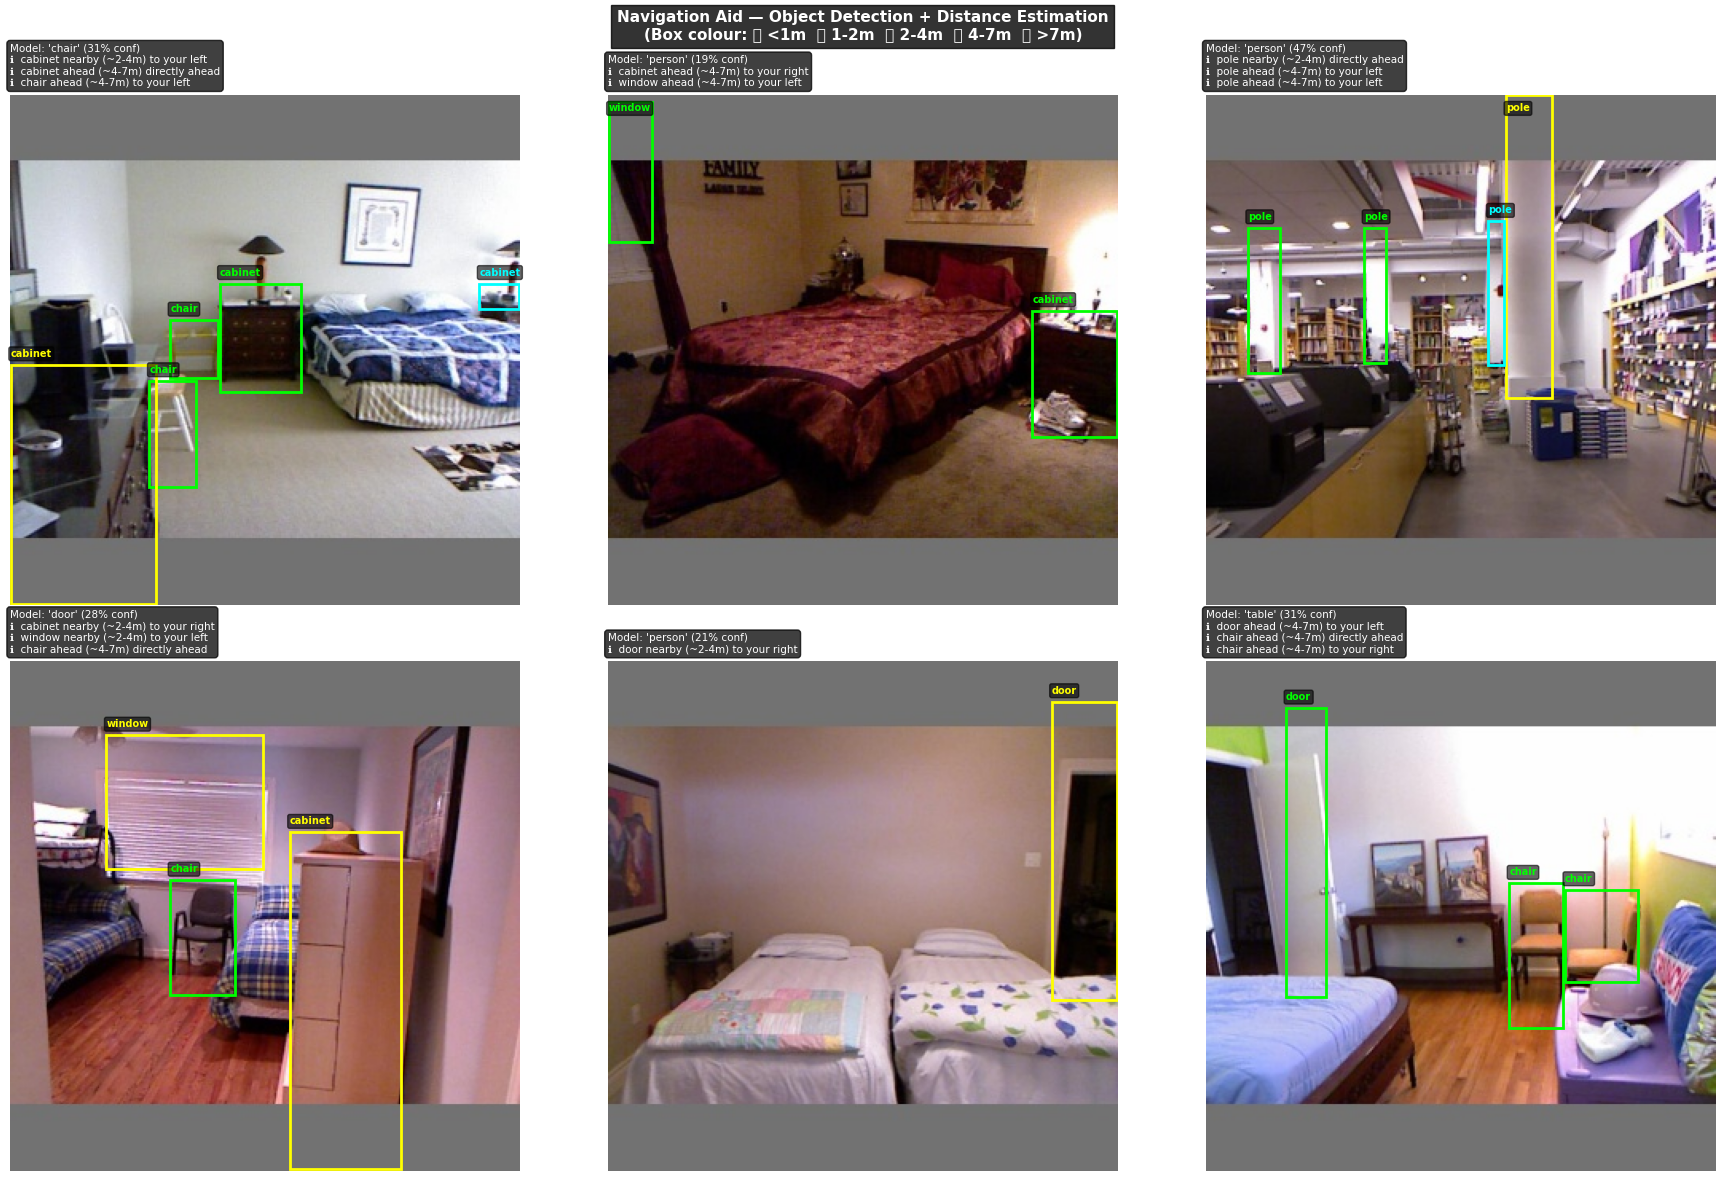


Saved to: /content/drive/MyDrive/FYP/fyp-model/sample_predictions.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

NAVIGATION_CLASSES = {
    0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle',
    4: 'bus', 5: 'truck', 6: 'traffic light', 7: 'stop sign',
    8: 'bench', 9: 'chair', 10: 'couch', 11: 'table',
    12: 'door', 13: 'window', 14: 'cabinet', 15: 'pole',
    16: 'stairs', 17: 'dog', 18: 'cat', 19: 'fire hydrant', 20: 'object'
}

def estimate_distance_from_box(bw, bh):
    """
    Estimate distance zone from bounding box size.
    Larger box = object is closer to camera.
    Returns distance label and zone.
    """
    box_area = bw * bh

    if box_area > 0.35:
        return "very close (< 1m)",   "DANGER"
    elif box_area > 0.15:
        return "close (~1-2m)",        "WARNING"
    elif box_area > 0.05:
        return "nearby (~2-4m)",       "CAUTION"
    elif box_area > 0.01:
        return "ahead (~4-7m)",        "INFO"
    else:
        return "far away (> 7m)",      "OK"


def get_position(cx):
    """Estimate left/centre/right from bounding box centre x"""
    if cx < 0.35:
        return "to your left"
    elif cx > 0.65:
        return "to your right"
    else:
        return "directly ahead"


def generate_audio_alert(detections):
    """
    Generate natural language audio alerts from detections.
    Similar to what the earpiece would announce.
    """
    if not detections:
        return "Path appears clear."

    alerts = []
    # Sort by danger level — closest first
    detections_sorted = sorted(
        detections,
        key=lambda d: d['box_area'],
        reverse=True
    )

    for det in detections_sorted[:3]:  # Max 3 alerts to avoid overload
        name     = det['class_name']
        distance = det['distance_label']
        position = det['position']
        zone     = det['zone']

        if zone == "DANGER":
            alerts.append(f"⚠️  WARNING — {name} {distance} {position}!")
        elif zone == "WARNING":
            alerts.append(f"🔶 Caution — {name} {distance} {position}")
        else:
            alerts.append(f"ℹ️  {name} {distance} {position}")

    return "\n".join(alerts)


def visualise_predictions(model, test_images, test_labels,
                           label_dir, img_dir, n=6):
    """
    Show sample images with:
    - Detected object class
    - Estimated distance
    - Position (left/centre/right)
    - Audio alert message
    - Bounding boxes from label files
    """
    class_names_inv = NAVIGATION_CLASSES
    img_files = list(Path(img_dir).glob('*.jpg'))[:n*3]
    random.shuffle(img_files)
    img_files = img_files[:n]

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, img_path in enumerate(img_files):
        if i >= n:
            break

        # Load original image for display
        orig = cv2.imread(str(img_path))
        orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
        h, w = orig.shape[:2]

        # Load for model prediction
        img_resized = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
        img_norm    = img_resized / 255.0
        img_input   = np.expand_dims(img_norm, axis=0).astype(np.float32)

        # Model prediction
        preds     = model.predict(img_input, verbose=0)
        pred_cls  = int(np.argmax(preds[0]))
        confidence = float(np.max(tf.nn.softmax(preds[0])))
        pred_name  = class_names_inv.get(pred_cls, 'unknown')

        # Load bounding boxes from label file
        label_path = Path(label_dir) / (img_path.stem + '.txt')
        detections = []

        axes[i].imshow(orig)

        if label_path.exists():
            with open(label_path) as f:
                lines = [l.strip() for l in f if l.strip()]

            for line in lines:
                parts = line.split()
                if len(parts) == 5:
                    cls_id = int(parts[0])
                    cx, cy, bw, bh = float(parts[1]), float(parts[2]), \
                                      float(parts[3]), float(parts[4])

                    # Draw bounding box
                    x1 = int((cx - bw/2) * w)
                    y1 = int((cy - bh/2) * h)
                    box_w = int(bw * w)
                    box_h = int(bh * h)

                    dist_label, zone = estimate_distance_from_box(bw, bh)
                    position = get_position(cx)
                    class_name = class_names_inv.get(cls_id, 'object')

                    # Color by zone
                    color = {'DANGER': 'red', 'WARNING': 'orange',
                             'CAUTION': 'yellow', 'INFO': 'lime',
                             'OK': 'cyan'}.get(zone, 'white')

                    rect = patches.Rectangle(
                        (x1, y1), box_w, box_h,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    axes[i].add_patch(rect)

                    # Label on box
                    axes[i].text(
                        x1, max(y1-5, 10),
                        f"{class_name}",
                        color=color, fontsize=7, weight='bold',
                        bbox=dict(boxstyle='round,pad=0.2',
                                  facecolor='black', alpha=0.6)
                    )

                    detections.append({
                        'class_name'   : class_name,
                        'distance_label': dist_label,
                        'position'      : position,
                        'zone'          : zone,
                        'box_area'      : bw * bh
                    })

        # Generate audio alert
        alert = generate_audio_alert(detections)

        # Title with prediction + alert
        title = (
            f"Model: '{pred_name}' ({confidence:.0%} conf)\n"
            f"{alert}"
        )
        axes[i].set_title(title, fontsize=7.5, loc='left',
                          color='white',
                          bbox=dict(boxstyle='round', facecolor='black',
                                    alpha=0.75))
        axes[i].axis('off')

    plt.suptitle(
        'Navigation Aid — Object Detection + Distance Estimation\n'
        '(Box colour: 🔴 <1m  🟠 1-2m  🟡 2-4m  🟢 4-7m  🔵 >7m)',
        fontsize=11, weight='bold', color='white',
        bbox=dict(facecolor='black', alpha=0.8)
    )
    plt.tight_layout()
    plt.savefig(
        f'{MODEL_SAVE_PATH}/sample_predictions.png',
        dpi=150, bbox_inches='tight', facecolor='black'
    )
    plt.show()
    print(f"\nSaved to: {MODEL_SAVE_PATH}/sample_predictions.png")


# Load best saved model and run visualisation
best_model = tf.keras.models.load_model(
    f'{MODEL_SAVE_PATH}/baseline_best.keras'
)

visualise_predictions(
    model     = best_model,
    test_images = test_images,
    test_labels = test_labels,
    label_dir = f'{DATASET_PATH}/test/labels',
    img_dir   = f'{DATASET_PATH}/test/images',
    n=6
)

In [ ]:
print("=" * 55)
print("FINAL MODEL TRAINING SUMMARY")
print("=" * 55)
print(f"\nDataset:")
print(f"  Train : {len(train_images)} images")
print(f"  Val   : {len(val_images)} images")
print(f"  Test  : {len(test_images)} images")
print(f"  Classes: {NC} navigation classes")
print(f"\nAccuracy:")
print(f"  Baseline (before pruning) : {baseline_accuracy:.4f} ({baseline_accuracy*100:.1f}%)")
print(f"  After pruning             : {pruned_accuracy:.4f} ({pruned_accuracy*100:.1f}%)")
print(f"  Accuracy retained         : {pruned_accuracy/baseline_accuracy*100:.1f}%")
print(f"\nModel sizes (compressed):")
print(f"  Baseline Keras     : {get_gzipped_model_size(baseline_keras_path)/1024:.0f} KB")
print(f"  Pruned Keras       : {get_gzipped_model_size(pruned_keras_path)/1024:.0f} KB")
print(f"  Pruned TFLite      : {get_gzipped_model_size(pruned_tflite_path)/1024:.0f} KB")
print(f"  Quantized+Pruned   : {get_gzipped_model_size(final_tflite_path)/1024:.0f} KB ← Deploy this")
print(f"\nFiles saved to Drive:")
print(f"  {baseline_keras_path}")
print(f"  {pruned_keras_path}")
print(f"  {pruned_tflite_path}")
print(f"  {final_tflite_path}")
print(f"  {MODEL_SAVE_PATH}/sample_predictions.png")
print("=" * 55)

FINAL MODEL TRAINING SUMMARY

Dataset:
  Train : 2718 images
  Val   : 354 images
  Test  : 238 images
  Classes: 21 navigation classes

Accuracy:
  Baseline (before pruning) : 0.6008 (60.1%)
  After pruning             : 0.5084 (50.8%)
  Accuracy retained         : 84.6%

Model sizes (compressed):
  Baseline Keras     : 3341 KB
  Pruned Keras       : 1757 KB
  Pruned TFLite      : 1657 KB
  Quantized+Pruned   : 527 KB ← Deploy this

Files saved to Drive:
  /content/drive/MyDrive/FYP/fyp-model/baseline_model.keras
  /content/drive/MyDrive/FYP/fyp-model/pruned_model.keras
  /content/drive/MyDrive/FYP/fyp-model/pruned_model.tflite
  /content/drive/MyDrive/FYP/fyp-model/fyp_navigation_model.tflite
  /content/drive/MyDrive/FYP/fyp-model/sample_predictions.png
